# Along-Track SSH — Composition, Filtering, and Co-location with Gridded Products

Tour of the along-track SSH transformations in `xrtoolz.ocn`. We load a real CMEMS L3 along-track product (AltiKa, 5 days, Gulf Stream box), build sea-surface height from the altimetry convention, compare filtered against unfiltered, co-locate against the gridded L4 DUACS product, look at the spectrum the L3 filter resolves, derive a cross-track geostrophic velocity, and finally evaluate the GLORYS reanalysis diagnostics *along* the same track.

Each diagnostic gets the same five-part block as the kinematics notebook: ELI5 → formal definition → continuous equation → discretisation → interpretation.

Companion notebooks in this PR cover the gridded kinematics (`ocean_kinematics_glorys_duacs.ipynb`) and stratification (`ocean_stratification_glorys.ipynb`).

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

# Silence third-party deprecation noise that clutters the rendered notebook.
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message="dropping variables using `drop` is deprecated")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xrft

from xrtoolz import Augment, Graph, Input, Sequential, Signature
from xrtoolz.geo.operators import RemoveMean
from xrtoolz.interpolate import regrid_like
from xrtoolz.ocn import (
    calculate_ssh_unfiltered,
    coriolis_parameter,
)
from xrtoolz.ocn.operators import (
    CalculateSSHAlongtrack,
    Divergence,
    GeostrophicVelocities,
    KineticEnergy,
    OkuboWeiss,
    RelativeVorticity,
    StrainMagnitude,
)

ALONGTRACK_CACHE = Path("../../.cache/cmems_l3_alongtrack_gulfstream_2023-06.nc")
DUACS_CACHE = Path("../../.cache/duacs_gulfstream_2023-06.nc")
GLORYS_CACHE = Path("../../.cache/glorys12_3d_gulfstream_2023-06.nc")

## 1 — Load the three datasets

- **L3 along-track**: AltiKa drifting-phase observations over `[-70, -50] × [30, 45]`, 2023-06-01 → 06-05. One row per 1-Hz sample with `(sla_filtered, sla_unfiltered, mdt, lwe)`.
- **L4 gridded** (DUACS): the merged-altimetry, daily 1/8° product `adt`. We use it as the standard reference for "what altimetry says SSH is on a regular grid" — itself constructed from a multi-mission L3 ensemble that includes data like our AltiKa subset.
- **GLORYS12 3D**: the prognostic reanalysis we use in § 9 to show how to evaluate model diagnostics at the same alongtrack sample points.

In [2]:
l3 = xr.open_dataset(ALONGTRACK_CACHE)
duacs = xr.open_dataset(DUACS_CACHE).rename({"latitude": "lat", "longitude": "lon"}).isel(time=slice(0, 5))
glorys_raw = (
    xr.open_dataset(GLORYS_CACHE)
    .rename({"latitude": "lat", "longitude": "lon"})
    .isel(depth=0)
)
glorys_raw = glorys_raw.assign_coords(
    lat=("lat", np.linspace(float(glorys_raw.lat[0]), float(glorys_raw.lat[-1]), glorys_raw.sizes["lat"])),
    lon=("lon", np.linspace(float(glorys_raw.lon[0]), float(glorys_raw.lon[-1]), glorys_raw.sizes["lon"])),
)

print("L3:", dict(l3.sizes), list(l3.data_vars))
print("L4 DUACS:", dict(duacs.sizes), list(duacs.data_vars))
print("GLORYS:", dict(glorys_raw.sizes), list(glorys_raw.data_vars))

L3: {'track': 1359} ['sla_filtered', 'sla_unfiltered', 'mdt', 'lwe']
L4 DUACS: {'time': 5, 'lat': 120, 'lon': 160} ['adt']
GLORYS: {'time': 5, 'lat': 181, 'lon': 241} ['uo', 'vo', 'thetao', 'so', 'zos']


### Track geometry

AltiKa is a sun-synchronous drifting-phase mission, so the ground track sweeps gradually through the basin over the 5-day window. We split the 1359 observations into discrete *passes* by detecting time gaps > 60 s (one orbit revisits a lat band roughly every 100 min).

identified 8 passes; lengths: [243, 13, 123, 236, 215, 243, 204, 82]


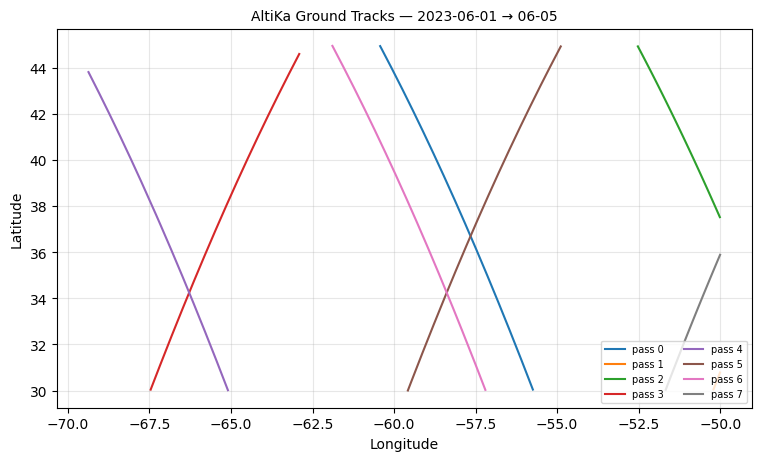

In [3]:
times = l3["time"].values
dt_sec = np.diff(times) / np.timedelta64(1, "s")
pass_starts = np.concatenate(([0], np.where(dt_sec > 60)[0] + 1, [len(times)]))
pass_indices = [np.arange(pass_starts[i], pass_starts[i + 1]) for i in range(len(pass_starts) - 1)]
print(f"identified {len(pass_indices)} passes; lengths: {[len(p) for p in pass_indices]}")

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
for k, idx in enumerate(pass_indices):
    ax.plot(l3["longitude"].values[idx], l3["latitude"].values[idx], "-", linewidth=1.5, label=f"pass {k}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("AltiKa Ground Tracks — 2023-06-01 → 06-05", fontsize=10)
ax.legend(fontsize=7, ncol=2, loc="lower right")
ax.grid(alpha=0.3)
plt.show()

## 2 — Altimetry convention preamble

A satellite altimeter does not measure SSH directly — it measures the *range* between the spacecraft and the ocean surface, then subtracts known geophysical corrections. The product chain delivers three quantities the user is meant to recombine:

- **SLA** (sea-level anomaly): the deviation from a long-term mean SSH. Two flavours are shipped: ``sla_unfiltered`` (raw 1-Hz) and ``sla_filtered`` (Lanczos-style high-pass + low-pass that suppresses noise above the geophysical signal).
- **MDT** (mean dynamic topography): the time-mean of SSH from a separate climatology — typically the CNES-CLS MDT product, derived from in-situ + altimetry + GRACE.
- **LWE** (loading water equivalent): a barotropic loading correction (essentially equivalent water depth from large-scale ocean tides + atmosphere). Subtracting it gives the dynamic ocean topography.

The two L3 transformations in `xrtoolz.ocn` each implement the standard altimetry composition formula, differing only in which SLA they consume:

$$
    \eta = \mathrm{SLA} + \mathrm{MDT} - \mathrm{LWE}.
$$

**Numerical methods.** Pure pointwise arithmetic — no derivatives are taken in this section. The complexity is conventional, not numerical: knowing which products to add and which to subtract.

## 3 — `calculate_ssh_alongtrack`

**ELI5.** Take the satellite's bumpiness reading (filtered SLA), add the time-mean topography (MDT), subtract the tide loading correction (LWE). What you get is the actual sea-surface height along the track.

**What it is.** The Layer-1 operator that composes filtered alongtrack SSH from the three altimetry building blocks. By default reads `sla_filtered`, `mdt`, `lwe` and writes `ssh`.

**Continuous formulation.**

$$
    \eta_{\text{filtered}}(t, \lambda, \varphi) = \mathrm{SLA}_{\text{filtered}}(t, \lambda, \varphi) + \mathrm{MDT}(\lambda, \varphi) - \mathrm{LWE}(t, \lambda, \varphi).
$$

**Discretisation.** None — the operator is a sum of three Datasets evaluated at the same alongtrack samples. The output gains attributes `units="m"`, `standard_name="sea_surface_height"`, `long_name="Sea Surface Height"`.

**Interpretation.** The filtered alongtrack SSH is the *observation* — the cleanest signal a single-mission altimeter delivers. It still has an irregular time/lat/lon footprint (one number per orbit-Hz sample), so it must be co-located with model output before quantitative comparison.

In [4]:
ssh_op = CalculateSSHAlongtrack(variable="ssh", sla="sla_filtered")
l3_with_ssh = ssh_op(l3)
print("after alongtrack:", list(l3_with_ssh.data_vars))
print(f"ssh: mean {float(l3_with_ssh['ssh'].mean()):.3f} m, std {float(l3_with_ssh['ssh'].std()):.3f} m")

after alongtrack: ['sla_filtered', 'sla_unfiltered', 'mdt', 'lwe', 'ssh']
ssh: mean 0.397 m, std 0.421 m


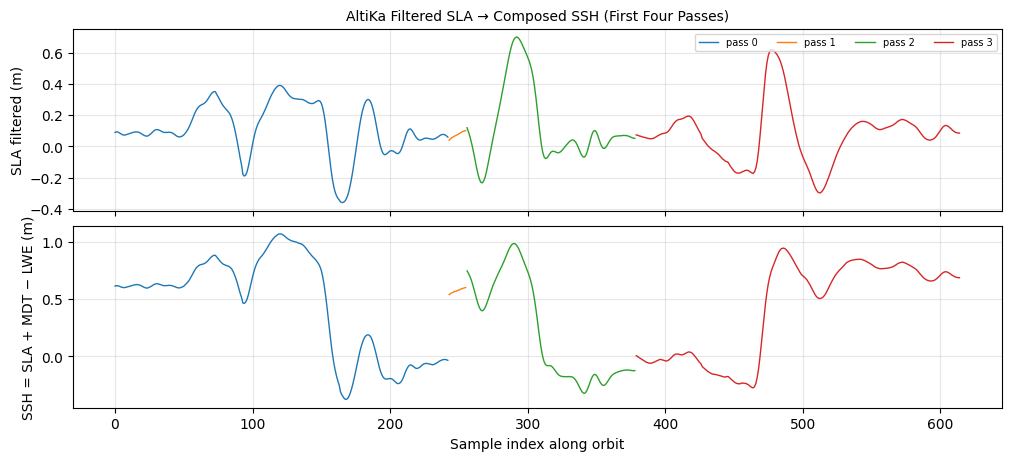

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True, constrained_layout=True)
for k, idx in enumerate(pass_indices[:4]):
    axes[0].plot(idx, l3_with_ssh["sla_filtered"].values[idx], linewidth=1.0, label=f"pass {k}")
    axes[1].plot(idx, l3_with_ssh["ssh"].values[idx], linewidth=1.0)
axes[0].set_ylabel("SLA filtered (m)")
axes[0].set_title("AltiKa Filtered SLA → Composed SSH (First Four Passes)", fontsize=10)
axes[0].legend(fontsize=7, ncol=4, loc="upper right")
axes[0].grid(alpha=0.3)
axes[1].set_ylabel("SSH = SLA + MDT − LWE (m)")
axes[1].set_xlabel("Sample index along orbit")
axes[1].grid(alpha=0.3)
plt.show()

## 4 — `calculate_ssh_unfiltered`

**ELI5.** Same recipe, but with the raw 1-Hz SLA (no smoothing applied at L3 production). Keeps the small-scale wiggles — both the real sub-mesoscale signal *and* the instrument noise.

**What it is.** The pure-function (Tier-A) variant pointing at `sla_unfiltered` instead of `sla_filtered`. There is no separate `Operator` wrapper because in practice you usually want one or the other in a pipeline, not both.

**Continuous formulation.**

$$
    \eta_{\text{unfiltered}} = \mathrm{SLA}_{\text{unfiltered}} + \mathrm{MDT} - \mathrm{LWE}.
$$

**Discretisation.** Same pointwise sum, different SLA input.

**Interpretation.** Unfiltered SSH is closer to the raw observation but inherits the high-frequency noise floor of the altimeter (~ 2 cm RMS at 1 Hz for AltiKa). The L3 filter is a Lanczos-style finite-impulse-response that removes scales below ~ 60 km — a deliberate trade between spatial resolution and noise. The variance budget below quantifies the trade.

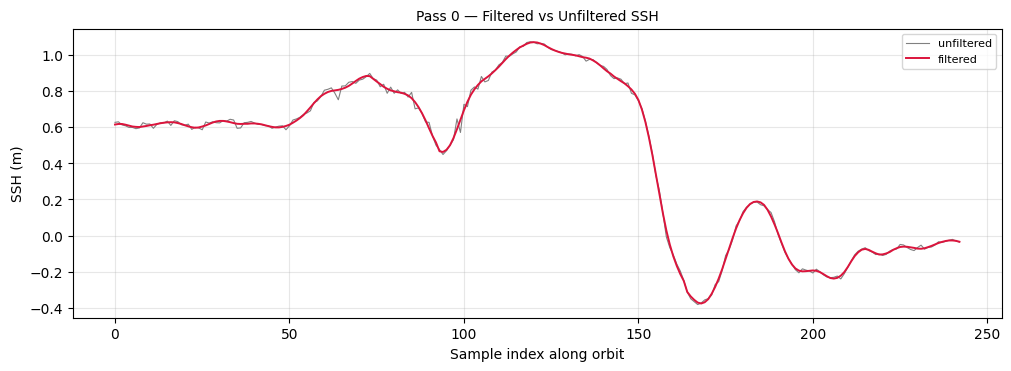

In [6]:
l3_with_uf = calculate_ssh_unfiltered(l3_with_ssh, variable="ssh_uf", sla="sla_unfiltered")

fig, ax = plt.subplots(figsize=(10, 3.6), constrained_layout=True)
idx = pass_indices[0]
ax.plot(idx, l3_with_uf["ssh_uf"].values[idx], color="grey", linewidth=0.8, label="unfiltered")
ax.plot(idx, l3_with_uf["ssh"].values[idx], color="crimson", linewidth=1.4, label="filtered")
ax.set_ylabel("SSH (m)")
ax.set_xlabel("Sample index along orbit")
ax.set_title("Pass 0 — Filtered vs Unfiltered SSH", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 5 — Filter residual: variance budget

**ELI5.** Subtract the smooth signal from the noisy one. What's left over is what the L3 filter removed.

**What it is.** The residual $\eta_{\text{unfiltered}} - \eta_{\text{filtered}}$ isolates the small-scale variance the L3 production pipeline judges to be below the geophysical signal floor. Computing its variance ratio against the filtered signal quantifies the trade-off between spatial resolution and noise.

**Continuous formulation.**

$$
    r(s) = \eta_{\text{unfiltered}}(s) - \eta_{\text{filtered}}(s),
    \qquad
    \rho_{\text{noise}} = \frac{\mathrm{Var}\,r}{\mathrm{Var}\,\eta_{\text{filtered}}}.
$$

**Discretisation.** Pointwise difference; variances over the full sample.

**Interpretation.** A small noise ratio (typical: 5-15 %) means the filter discards mostly noise. A large one indicates the filter is throwing away real signal — usually a hint that the configured cut-off is too aggressive for the regime of interest (sub-mesoscale fronts in the Gulf Stream, for instance, can sit right at the filter's stop band).

Var(filtered SSH) = 0.17727 m²
Var(residual)     = 0.00020 m²
noise/signal var ratio = 0.114%


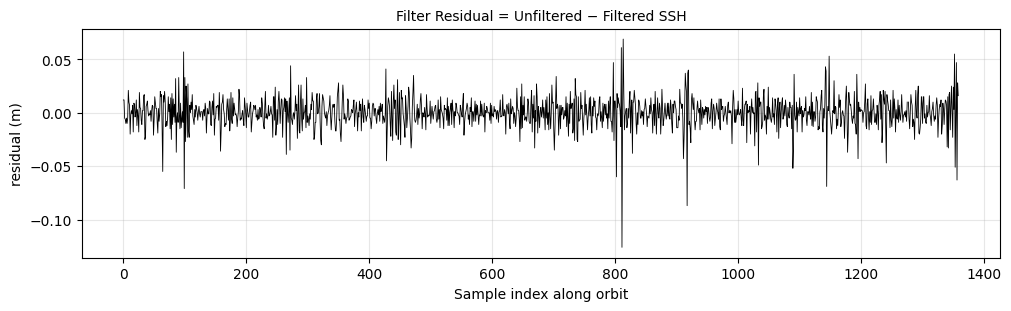

In [7]:
residual = l3_with_uf["ssh_uf"] - l3_with_uf["ssh"]
var_signal = float(l3_with_uf["ssh"].var())
var_residual = float(residual.var())
ratio = var_residual / var_signal
print(f"Var(filtered SSH) = {var_signal:.5f} m²")
print(f"Var(residual)     = {var_residual:.5f} m²")
print(f"noise/signal var ratio = {ratio:.3%}")

fig, ax = plt.subplots(figsize=(10, 3.0), constrained_layout=True)
ax.plot(np.arange(len(residual)), residual.values, linewidth=0.6, color="black")
ax.set_ylabel("residual (m)")
ax.set_xlabel("Sample index along orbit")
ax.set_title("Filter Residual = Unfiltered − Filtered SSH", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## 6 — Co-location with the L4 gridded DUACS product

**ELI5.** For every alongtrack point, pick the closest L4 grid cell at the same time. Compare. The L3 sees what one satellite saw at one instant; the L4 is a multi-mission analysis on a regular grid.

**What it is.** The standard altimetry-validation pattern: bilinear-interpolate the gridded L4 product onto the irregular `(t, \text{lat}, \text{lon})` of the L3 observations and compute pointwise difference statistics.

**Continuous formulation.** With $\Pi$ the bilinear-interpolation operator on the L4 grid:

$$
    \eta_{\text{L4 at L3}}(t_i, \lambda_i, \varphi_i) = \Pi\bigl[\eta_{\text{L4}}\bigr](t_i, \lambda_i, \varphi_i).
$$

**Discretisation.** `xr.Dataset.interp(time=..., lat=..., lon=...)` runs xarray's vectorised bilinear interpolation. We then compute RMSE and correlation between the two SSH fields. We de-mean each side first because the L3 SSH carries an absolute reference (MDT included) while DUACS `adt` is on a slightly different geoid — the meaningful comparison is variance-relative, not absolute.

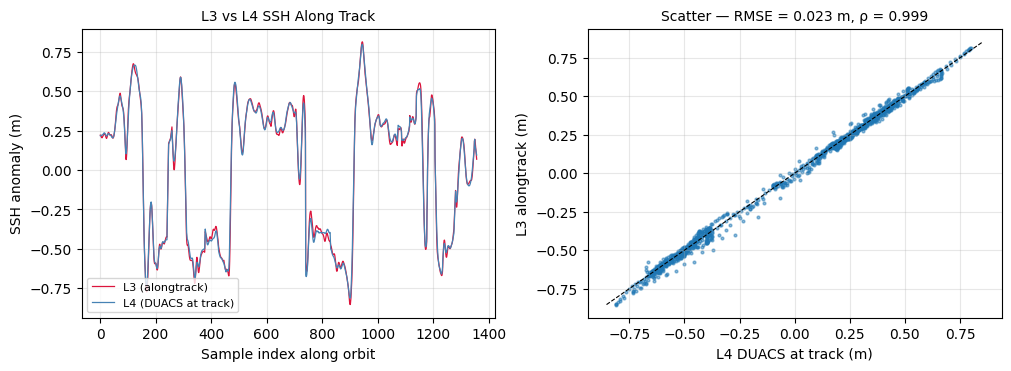

In [8]:
duacs_at_track = duacs["adt"].interp(
    time=l3_with_ssh["time"],
    lat=l3_with_ssh["latitude"],
    lon=l3_with_ssh["longitude"],
)
ssh_l3 = l3_with_ssh["ssh"] - l3_with_ssh["ssh"].mean()
ssh_l4 = duacs_at_track - duacs_at_track.mean()
finite = np.isfinite(ssh_l3.values) & np.isfinite(ssh_l4.values)
rmse = float(np.sqrt(((ssh_l3.values - ssh_l4.values) ** 2)[finite].mean()))
corr = float(np.corrcoef(ssh_l3.values[finite], ssh_l4.values[finite])[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
axes[0].plot(np.arange(len(ssh_l3))[finite], ssh_l3.values[finite], color="crimson", linewidth=0.9, label="L3 (alongtrack)")
axes[0].plot(np.arange(len(ssh_l4))[finite], ssh_l4.values[finite], color="steelblue", linewidth=0.9, label="L4 (DUACS at track)")
axes[0].set_xlabel("Sample index along orbit")
axes[0].set_ylabel("SSH anomaly (m)")
axes[0].set_title("L3 vs L4 SSH Along Track", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].scatter(ssh_l4.values[finite], ssh_l3.values[finite], s=4, alpha=0.5)
lim = max(np.abs(ssh_l3.values[finite]).max(), np.abs(ssh_l4.values[finite]).max())
axes[1].plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8)
axes[1].set_xlabel("L4 DUACS at track (m)")
axes[1].set_ylabel("L3 alongtrack (m)")
axes[1].set_title(f"Scatter — RMSE = {rmse:.3f} m, ρ = {corr:.3f}", fontsize=10)
axes[1].grid(alpha=0.3)
plt.show()

## 7 — Power spectrum along the orbit

**ELI5.** Take one continuous orbit pass, expand it into sine waves of different wavelengths, and plot how much energy sits at each wavelength. Long wavelengths are gyres and basin-scale flow; short wavelengths are eddies and sub-mesoscale fronts.

**What it is.** A 1-D power spectrum of $\eta(s)$ along arc length $s$. The L3 filter's cut-off shows up as a clear roll-off at small wavelengths (high wavenumbers); the L4 (gridded reconstruction) has even less energy at the smallest scales because the optimal-interpolation analysis smears information across crossing tracks.

**Continuous formulation.**

$$
    \hat{\eta}(k) = \int \eta(s)\,e^{-i 2\pi k s}\,\mathrm{d}s,
    \qquad
    P(k) = |\hat{\eta}(k)|^2.
$$

**Discretisation.** We pick one continuous pass, compute arc-length $s_i$ via the haversine formula between consecutive points, resample onto a uniform $s$ grid (FFT requires uniform sampling), then call `xrft.power_spectrum`.

**Interpretation.** The expected slope is ≈ $k^{-2}$ in the mesoscale band (50-500 km wavelength) for a quasi-geostrophic ocean — diagnostic of the mesoscale energy cascade. A spectrum that flattens at small scales indicates the noise floor is being reached; a steepening flag indicates an over-aggressive filter.

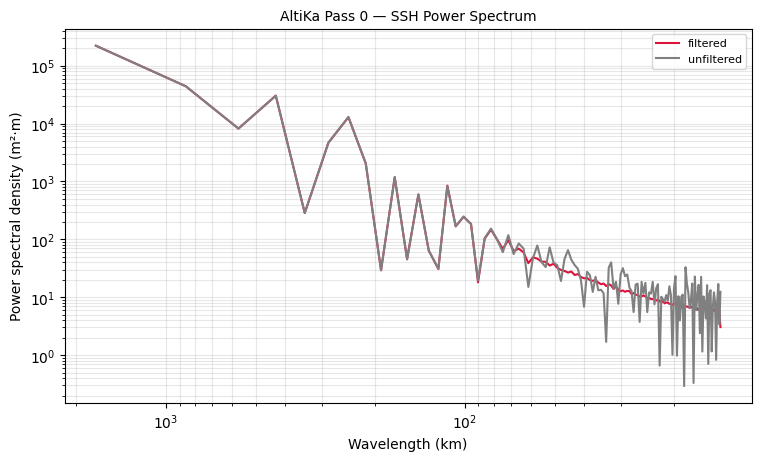

In [9]:
def haversine_arc_length(lat: np.ndarray, lon: np.ndarray, *, R: float = 6_371_000.0) -> np.ndarray:
    """Cumulative arc length along a sequence of (lat, lon) points, in metres."""
    lat_r = np.deg2rad(lat)
    lon_r = np.deg2rad(lon)
    dlat = np.diff(lat_r)
    dlon = np.diff(lon_r)
    a = np.sin(dlat / 2) ** 2 + np.cos(lat_r[:-1]) * np.cos(lat_r[1:]) * np.sin(dlon / 2) ** 2
    seg = 2 * R * np.arcsin(np.sqrt(a))
    return np.concatenate(([0.0], np.cumsum(seg)))


idx = pass_indices[0]
lat_p = l3_with_ssh["latitude"].values[idx]
lon_p = l3_with_ssh["longitude"].values[idx]
ssh_p = l3_with_ssh["ssh"].values[idx]
ssh_uf_p = l3_with_uf["ssh_uf"].values[idx]
s = haversine_arc_length(lat_p, lon_p)

# Resample onto uniform arc-length grid (~7 km nominal AltiKa 1-Hz spacing).
ds_uniform = float(np.median(np.diff(s)))
s_u = np.arange(s[0], s[-1], ds_uniform)
ssh_u = np.interp(s_u, s, ssh_p)
ssh_uf_u = np.interp(s_u, s, ssh_uf_p)

ssh_da = xr.DataArray(ssh_u, dims=("s",), coords={"s": s_u})
ssh_uf_da = xr.DataArray(ssh_uf_u, dims=("s",), coords={"s": s_u})
ps_filt = xrft.power_spectrum(ssh_da - ssh_da.mean(), dim="s", real_dim="s").compute()
ps_uf = xrft.power_spectrum(ssh_uf_da - ssh_uf_da.mean(), dim="s", real_dim="s").compute()

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
k_filt = ps_filt["freq_s"].values
k_uf = ps_uf["freq_s"].values
mask_f = k_filt > 0
mask_u = k_uf > 0
ax.loglog(1.0 / k_filt[mask_f] / 1e3, ps_filt.values[mask_f], color="crimson", label="filtered")
ax.loglog(1.0 / k_uf[mask_u] / 1e3, ps_uf.values[mask_u], color="grey", label="unfiltered")
ax.set_xlabel("Wavelength (km)")
ax.set_ylabel("Power spectral density (m²·m)")
ax.set_title("AltiKa Pass 0 — SSH Power Spectrum", fontsize=10)
ax.invert_xaxis()
ax.grid(which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

## 8 — Cross-track geostrophic velocity

**ELI5.** Ride along the satellite's path. The slope of SSH along the track tells you which way the water is flowing across the track, and how fast.

**What it is.** The geostrophic velocity component perpendicular to the satellite ground track, derived from the alongtrack SSH gradient. A single altimeter cannot resolve both $u$ and $v$ at a point — only the cross-track component is observable from one pass; recovering the full vector requires crossing tracks (the L4 product solves this via optimal interpolation).

**Continuous formulation.** Let $s$ be arc length along the track and $\hat{n}$ the unit cross-track normal. Then

$$
    v_\perp(s) = \frac{g}{f(\varphi(s))}\,\frac{\partial \eta}{\partial s},
$$

with $g = 9.80665$ m/s² and $f(\varphi)$ from `coriolis_parameter`.

**Discretisation.** We use the same haversine arc length as § 7 and `np.gradient(eta, s)` for $\partial\eta/\partial s$ — equivalent to a central finite difference on a possibly non-uniform grid. The same operation applied to the unfiltered SSH amplifies its noise floor: differentiation in physical space is a high-pass filter, so any small high-frequency wiggle in $\eta$ becomes a much larger wiggle in $\partial\eta/\partial s$. This is exactly why the L3 filter exists.

`xrtoolz.ocn.geostrophic_velocities` is **not** used here because it operates on 2-D lat/lon grids; for irregular 1-D tracks an arc-length-aware helper is the right tool. If this pattern recurs, it's a candidate for promotion to the library as `alongtrack_geostrophic_velocity`.

**Interpretation.** Cross-track velocity is the standard observable for altimetry-based skill scores — model evaluation reports often quote "RMS error in cross-track velocity" rather than "RMS error in SSH". Fronts show up as sharp spikes in $v_\perp$; eddies as oscillations of alternating sign as the track crosses them.

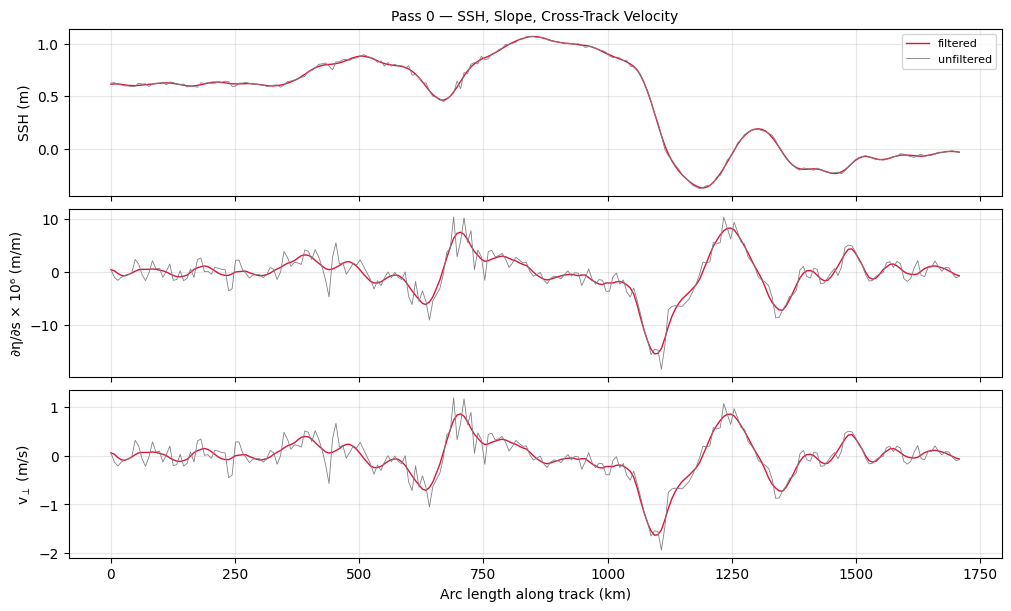

In [10]:
g = 9.80665


def cross_track_velocity(lat: np.ndarray, lon: np.ndarray, eta: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (s, deta_ds, v_perp) for a single continuous pass."""
    s = haversine_arc_length(lat, lon)
    deta_ds = np.gradient(eta, s)
    f = coriolis_parameter(xr.DataArray(lat, dims=("track",))).values
    v_perp = (g / f) * deta_ds
    return s, deta_ds, v_perp


s_filt, deta_ds_filt, vperp_filt = cross_track_velocity(lat_p, lon_p, ssh_p)
_, deta_ds_uf, vperp_uf = cross_track_velocity(lat_p, lon_p, ssh_uf_p)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
axes[0].plot(s_filt / 1e3, ssh_p, color="crimson", linewidth=1.0, label="filtered")
axes[0].plot(s_filt / 1e3, ssh_uf_p, color="grey", linewidth=0.6, label="unfiltered")
axes[0].set_ylabel("SSH (m)")
axes[0].set_title("Pass 0 — SSH, Slope, Cross-Track Velocity", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(s_filt / 1e3, deta_ds_filt * 1e6, color="crimson", linewidth=1.0)
axes[1].plot(s_filt / 1e3, deta_ds_uf * 1e6, color="grey", linewidth=0.6)
axes[1].set_ylabel("∂η/∂s × 10⁶ (m/m)")
axes[1].grid(alpha=0.3)

axes[2].plot(s_filt / 1e3, vperp_filt, color="crimson", linewidth=1.0)
axes[2].plot(s_filt / 1e3, vperp_uf, color="grey", linewidth=0.6)
axes[2].set_ylabel("v$_\\perp$ (m/s)")
axes[2].set_xlabel("Arc length along track (km)")
axes[2].grid(alpha=0.3)
plt.show()

## 9 — Co-locate gridded GLORYS kinematic diagnostics along the track

**ELI5.** Take the model. Build all the diagnostics from the kinematics notebook (vorticity, KE, Okubo-Weiss, …). Then ask the model: "what does each of those diagnostics look like at the exact place and time the satellite was when it took its observation?" That's how you compare a continuous model field to a sparse, irregular satellite track.

**What it is.** The standard model-vs-observation evaluation pipeline. A `Sequential` of `Augment(diagnostic)` ops is applied to GLORYS once, producing a Dataset with vorticity, KE, divergence, Okubo-Weiss, etc. as additional variables. The whole augmented Dataset is then sampled at each L3 alongtrack point via `xr.Dataset.interp`. The resulting alongtrack series of *model diagnostics* can be compared to the observed cross-track velocity (§ 8) or to any other alongtrack-derived signal.

**Continuous formulation.** With $\mathcal{D}$ a diagnostic operator (e.g. relative vorticity) and $\Pi$ bilinear interpolation:

$$
    \mathcal{D}_{\text{model along track}}(s_i) = \Pi\bigl[\mathcal{D}(\mathbf{u}_{\text{model}})\bigr](t_i, \lambda_i, \varphi_i).
$$

**Discretisation.** Three steps:

1. Regrid GLORYS to a 0.25° lat/lon target via `regrid_like` (consistent with the kinematics notebook).
2. Build the diagnostics in one pass with `Sequential([Augment(RelativeVorticity()), Augment(Divergence()), Augment(KineticEnergy()), Augment(StrainMagnitude()), Augment(OkuboWeiss())])`.
3. `augmented.interp(time=…, lat=…, lon=…)` over the alongtrack `(time, lat, lon)` arrays — vectorised xarray bilinear interpolation.

**Interpretation.** This is the same diagnostic suite used to evaluate models against drifters, gliders, ARGO floats, and altimeters. The L3 alongtrack co-location is the cleanest test for SSH-related diagnostics; for velocity diagnostics, model bias against the observed cross-track velocity (§ 8 vs § 9) directly reflects the model's ability to reproduce the geostrophic mesoscale.

In [11]:
target = xr.Dataset(
    coords={
        "lat": ("lat", np.arange(30.0, 45.01, 0.25), {"units": "degrees_north"}),
        "lon": ("lon", np.arange(-70.0, -49.99, 0.25), {"units": "degrees_east"}),
    }
)
glorys = (
    regrid_like(glorys_raw, target)
    .rename({"zos": "ssh", "uo": "u", "vo": "v"})[["ssh", "u", "v"]]
)

diagnostics = Sequential(
    [
        Augment(RelativeVorticity()),
        Augment(Divergence()),
        Augment(KineticEnergy()),
        Augment(StrainMagnitude()),
        Augment(OkuboWeiss()),
    ]
)

# Per-snapshot shape inference. The pipeline is applied per time-slice;
# describe() shows the operator structure, summary() the shape effects.
snapshot_signature = Signature(
    {k: v for k, v in glorys.isel(time=0).sizes.items()},
    dtype=str(glorys["ssh"].dtype),
)
print(diagnostics.describe())
print()
print(diagnostics.summary(snapshot_signature))

# Apply the pipeline per-time-snapshot, then re-stack so the result keeps the time dim.
glorys_aug = xr.concat(
    [diagnostics(glorys.isel(time=t)).expand_dims(time=[glorys.time.values[t]]) for t in range(glorys.sizes["time"])],
    dim="time",
)
print("GLORYS augmented columns:", list(glorys_aug.data_vars))

# Sample the augmented model along the L3 track.
glorys_at_track = glorys_aug.interp(
    time=l3_with_ssh["time"],
    lat=l3_with_ssh["latitude"],
    lon=l3_with_ssh["longitude"],
)
print("GLORYS-at-track diagnostics:", list(glorys_at_track.data_vars))

Sequential (5 ops)
├── Augment(inner={'class': 'RelativeVorticity', 'config': {'u': 'u', 'v': 'v'}})
├── Augment(inner={'class': 'Divergence', 'config': {'u': 'u', 'v': 'v'}})
├── Augment(inner={'class': 'KineticEnergy', 'config': {'u': 'u', 'v': 'v'}})
├── Augment(inner={'class': 'StrainMagnitude', 'config': {'u': 'u', 'v': 'v'}})
└── Augment(inner={'class': 'OkuboWeiss', 'config': {'u': 'u', 'v': 'v'}})

Sequential (5 ops)
Step  Operator                                  Input Signature                  Output Signature               
----  ----------------------------------------  -------------------------------  -------------------------------
0     Augment(RelativeVorticity(u='u', v='v'))  (lat=61, lon=81); dtype=float64  (lat=61, lon=81); dtype=float64
1     Augment(Divergence(u='u', v='v'))         (lat=61, lon=81); dtype=float64  (lat=61, lon=81); dtype=float64
2     Augment(KineticEnergy(u='u', v='v'))      (lat=61, lon=81); dtype=float64  (lat=61, lon=81); dtype=float64
3     

GLORYS augmented columns: ['ssh', 'u', 'v', 'vort_r', 'div', 'ke', 'strain', 'ow']
GLORYS-at-track diagnostics: ['ssh', 'u', 'v', 'vort_r', 'div', 'ke', 'strain', 'ow']


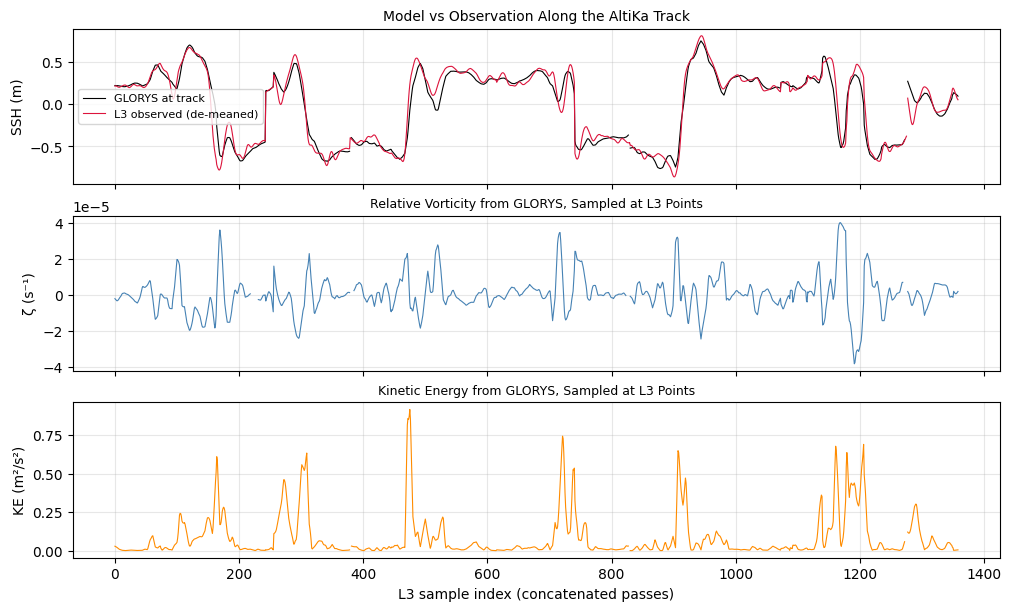

In [12]:
n_track = glorys_at_track.sizes["track"]
sample_idx = np.arange(n_track)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
axes[0].plot(sample_idx, glorys_at_track["ssh"].values, color="black", linewidth=0.8, label="GLORYS at track")
axes[0].plot(
    sample_idx,
    l3_with_ssh["ssh"].values - float(l3_with_ssh["ssh"].mean()) + float(glorys_aug["ssh"].mean()),
    color="crimson", linewidth=0.8, label="L3 observed (de-meaned)",
)
axes[0].set_ylabel("SSH (m)")
axes[0].set_title("Model vs Observation Along the AltiKa Track", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(sample_idx, glorys_at_track["vort_r"].values, color="steelblue", linewidth=0.8)
axes[1].set_ylabel("ζ (s⁻¹)")
axes[1].set_title("Relative Vorticity from GLORYS, Sampled at L3 Points", fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(sample_idx, glorys_at_track["ke"].values, color="darkorange", linewidth=0.8)
axes[2].set_ylabel("KE (m²/s²)")
axes[2].set_xlabel("L3 sample index (concatenated passes)")
axes[2].set_title("Kinetic Energy from GLORYS, Sampled at L3 Points", fontsize=9)
axes[2].grid(alpha=0.3)
plt.show()

## 10 — Bonus: a `Sequential` ingest pipeline

The standard L3 alongtrack ingest collapses to one `Sequential`: compose SSH, augment with the unfiltered SSH for downstream filter-budget work, and a `Tap` to log basic stats — fully reusable across any L3 product that ships the conventional `(sla_*, mdt, lwe)` variables.

In [13]:
from xrtoolz import Tap


def report_ssh(ds: xr.Dataset) -> None:
    print(f"  ssh: mean {float(ds['ssh'].mean()):.3f} m, std {float(ds['ssh'].std()):.3f} m, n={ds.sizes['track']}")


ingest = Sequential(
    [
        Augment(CalculateSSHAlongtrack(variable="ssh", sla="sla_filtered")),
        Tap(report_ssh, name="ssh_stats"),
    ]
)
print(ingest.describe())
print()
l3_signature = Signature(
    dict(l3.sizes), dtype=str(l3["sla_filtered"].dtype),
)
print(ingest.summary(l3_signature))
print("Running ingest:")
_ = ingest(l3)

Sequential (2 ops)
├── Augment(inner={'class': 'CalculateSSHAlongtrack', 'config': {'variable': 'ssh', 'sla': 'sla_filtered', 'mdt': 'mdt', 'lwe': 'lwe'}})
└── Tap(name='ssh_stats', side_effect='<callable>')

Sequential (2 ops)
Step  Operator                                                                                   Input Signature              Output Signature           
----  -----------------------------------------------------------------------------------------  ---------------------------  ---------------------------
0     Augment(CalculateSSHAlongtrack(variable='ssh', sla='sla_filtered', mdt='mdt', lwe='lwe'))  (track=1359); dtype=float64  (track=1359); dtype=float64
1     Tap(name='ssh_stats')                                                                      (track=1359); dtype=float64  (track=1359); dtype=float64
Running ingest:
  ssh: mean 0.397 m, std 0.421 m, n=1359


## 11 — Bonus: `Graph` DAG with one `Input(name='l3')`

Same ingest expressed as a DAG with one input and two terminal SSH nodes (filtered and unfiltered) — convenient when downstream code needs each output as its own object instead of merged into the input.

In [14]:
l3_in = Input(name="l3")
filtered_node = CalculateSSHAlongtrack(variable="ssh", sla="sla_filtered")(l3_in)
unfiltered_node = CalculateSSHAlongtrack(variable="ssh_uf", sla="sla_unfiltered")(l3_in)

scorecard = Graph(
    inputs={"l3": l3_in},
    outputs={"filtered": filtered_node, "unfiltered": unfiltered_node},
)
scorecard

Graph(inputs=['l3'], outputs=['filtered', 'unfiltered'])

In [15]:
out = scorecard(l3=l3)
filtered_summary = pd.Series(
    {
        "filtered SSH std (m)": float(out["filtered"]["ssh"].std()),
        "unfiltered SSH std (m)": float(out["unfiltered"]["ssh_uf"].std()),
        "filter-removed std (m)": float((out["unfiltered"]["ssh_uf"] - out["filtered"]["ssh"]).std()),
    },
    name="value",
).to_frame()
filtered_summary

,value
filtered SSH std (m),0.421034
unfiltered SSH std (m),0.421461
filter-removed std (m),0.014237


## 12 — Rebuilding the L3 cache

```python
import copernicusmarine as cm
import pandas as pd, numpy as np, xarray as xr

df = cm.read_dataframe(
    dataset_id="cmems_obs-sl_glo_phy-ssh_my_alg-l3-duacs_PT1S",
    variables=["sla_filtered", "sla_unfiltered", "mdt", "lwe"],
    minimum_longitude=-70.0, maximum_longitude=-50.0,
    minimum_latitude=30.0,   maximum_latitude=45.0,
    start_datetime="2023-06-01", end_datetime="2023-06-05",
)
wide = df.pivot_table(
    index=["time", "longitude", "latitude"], columns="variable", values="value"
).reset_index()
wide["time"] = pd.to_datetime(wide["time"])
wide = wide.sort_values("time").reset_index(drop=True)

ds = xr.Dataset(
    {col: (("track",), wide[col].values)
     for col in ["sla_filtered", "sla_unfiltered", "mdt", "lwe"]},
    coords={
        "track": np.arange(len(wide)),
        "time": (("track",), wide["time"].values),
        "longitude": (("track",), wide["longitude"].values),
        "latitude": (("track",), wide["latitude"].values),
    },
)
ds.to_netcdf(".cache/cmems_l3_alongtrack_gulfstream_2023-06.nc")
```